# 08 -- Nivel 1: pronóstico de demanda acumulada a 15 días

Octavo notebook de la cadena. Entrena y evalúa el Nivel 1 sobre `matriz_as_of.parquet` (07).

Dos decisiones metodológicas que el intento anterior no tomaba, y que son la diferencia
entre un número creíble y uno que no lo es:

**1. Se entrenan dos modelos por rama, no uno.** Un modelo cuantílico con `alpha=0.89`
sobre-predice a propósito: ése es su trabajo. Evaluarlo con WAPE -- que se optimiza con la
mediana -- lo castiga por hacer bien lo que se le pidió. Así que:

- **modelo q50** (`alpha=0.5`): es el que se compara contra el piso por WAPE. Mide capacidad
  predictiva.
- **modelo q_negocio** (`alpha` de la función de costo): es el que sale a producción. Se
  evalúa con *pinball loss* y con cobertura empírica, no con WAPE.

Confundir ambos fue lo que hizo que el intento anterior reportara una "mejora" comparando
un modelo q89 contra un piso de WAPE, y además contra la columna equivocada.

**2. Croston/SBA se prueba de verdad.** El 05 recomendó *probar* Croston para la rama
intermitente (71,1% del conjunto prioritario, grano diario). El intento anterior devolvía una media móvil
disfrazada de enrutamiento. Aquí se implementa SBA y se contrasta contra el piso interno: si
no gana, ese hallazgo negativo simplifica el enrutamiento y es publicable.

**3. Modelo por rama, no LightGBM uniforme (INV-62).** Tres rondas de búsqueda
registradas en MLflow: (a) 96 corridas con grid aleatorio
(`dw/buscar_hiperparametros_nivel1.py`, experimento `INV-62-nivel1-hparam-search`)
confirmaron que el default de 400 árboles/63 hojas sobreajustaba en las ramas suaves
(2.479 y 1.523 filas en toda la matriz); (b) 265 corridas bayesianas (`optuna`) más
otras familias de modelo (`dw/buscar_hiperparametros_nivel1_optuna.py`, experimento
`INV-62-nivel1-optuna-search`) encontraron que un GLM Tweedie le gana a los árboles
en las dos ramas suaves; (c) 22 corridas de **ensamble Tweedie+LightGBM**
(`dw/probar_ensamble_nivel1.py`, experimento `INV-62-nivel1-ensemble-search`) le
ganan a cualquiera de los dos solos -- sección 4 usa el ensamble en las ramas suaves
y LightGBM (afinado) en intermitente.

**4. Validación honesta de lo anterior (ronda 4, sección 8, puntos 4-6).** Desglose
por fold: `intermitente` gana en 3/4 folds y sigue ganando sin el fold 5 (resultado
razonablemente robusto); **`suave_no_perecedero` gana en gran parte por el fold 5**
(sin él, un empate técnico, no una pérdida clara -- ver INV-63 abajo). Dos intentos de
arreglar la calibración de `suave_perecedero` que NO funcionaron (hurdle: premisa
falsa, esa rama no tiene ceros; log-transform: explotó a 7x el piso) quedan
documentados para no repetirlos. Recalibración conformal mejoró la calibración.

**5. INV-63 -- bug real en `factor_calendario_ventana` (07), encontrado y corregido.**
Un heurístico de nombre de columna solo mapeaba 3 de 11 eventos de calendario con
efecto confirmado -- se perdían los de mayor efecto (fin de año 2.53x, nochebuena
1.63x, novena 1.46x, quincena, período de prima). Corregido con un mapeo explícito +
`assert` (ver `docs/INV-63-correccion-factor-calendario.md`). Se repitió la búsqueda
bayesiana + ensamble sobre la matriz corregida (esta vez probando LightGBM, Tweedie e
HistGB de a pares, no solo Tweedie+LightGBM) -- mejora en las 3 ramas: `intermitente`
0.423→0.416 (+3.3% sobre el piso), `suave_no_perecedero` 0.187→0.182 (+4.2%),
`suave_perecedero` 0.157→0.150 (sigue sin superar el piso, brecha menor). La
calibración también mejoró en las 3 -- `suave_no_perecedero` pasó a necesitar
recalibración conformal también (antes solo `suave_perecedero` la necesitaba).

Cadena: ... -> `06_diagnostico_inventario` -> `07_matriz_as_of` -> **`08_nivel1_demanda`**

In [1]:
import sys
sys.path.insert(0, '.')
from common_priorizacion import (
    PARAMS, DW, registrar_huella, verificar_huella, leer_panel, leer_calendario_habil,
)

import json
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.linear_model import TweedieRegressor
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

HORIZONTE = 15
ALPHA_CROSTON = 0.1     # suavizado clásico de Croston; 0.05-0.2 es el rango habitual
SEMILLA = 42

## 1. Costos: supuestos declarados, no resultados

Los parámetros de costo del intento anterior (0.10 / 0.25 / 0.03 / 0.20 / 1.00) no tienen
fuente, y la documentación los presentaba como derivados. Aquí se declaran explícitamente
como **supuestos a validar con el negocio**, y se acompañan de un análisis de sensibilidad
sobre el cuantil resultante.

Hay además una tensión de diseño que conviene dejar por escrito en la tesis: `Co = 1.00`
(merma total) para perecederos produce un cuantil de 0.17, es decir, **sub-pronosticar
sistemáticamente** los productos que la condición 2 priorizó precisamente porque el negocio
no quiere quedarse sin ellos. `Co = 1.00` sólo es defendible si el producto caduca dentro de
la ventana de 15 días, lo cual es cierto para fruta fresca y no para lácteos o embutidos.

In [2]:
COSTOS_SUPUESTOS = {
    'no_perecedero': {'Cu': 0.25, 'Co': 0.03, 'fuente': 'SUPUESTO -- pendiente de validar con el negocio'},
    'perecedero':    {'Cu': 0.20, 'Co': 1.00, 'fuente': 'SUPUESTO -- Co=1.0 asume merma total en <=15 días'},
}

def cuantil_optimo(Cu, Co):
    return Cu / (Cu + Co)

print('Cuantil óptimo bajo los supuestos actuales:')
for k, v in COSTOS_SUPUESTOS.items():
    print(f"  {k}: Cu={v['Cu']}, Co={v['Co']} -> q = {cuantil_optimo(v['Cu'], v['Co']):.3f}   [{v['fuente']}]")

print('\n--- SENSIBILIDAD DEL CUANTIL AL SUPUESTO DE COSTO ---')
rejilla = []
for Co in [0.03, 0.10, 0.25, 0.50, 1.00]:
    for Cu in [0.10, 0.20, 0.25, 0.40]:
        rejilla.append({'Cu': Cu, 'Co': Co, 'cuantil': round(cuantil_optimo(Cu, Co), 3)})
tabla_sens = pd.DataFrame(rejilla).pivot(index='Cu', columns='Co', values='cuantil')
print(tabla_sens)
print('\nLECTURA: el cuantil es muy sensible a Co. Pasar de Co=1.00 a Co=0.25 mueve el cuantil'
      ' de 0.17 a 0.44 para un perecedero. Mientras Co sea un supuesto, el cuantil de esa rama'
      ' debe reportarse como rango, no como valor único.')

ALPHA_NEGOCIO = {k: round(cuantil_optimo(v['Cu'], v['Co']), 3) for k, v in COSTOS_SUPUESTOS.items()}

Cuantil óptimo bajo los supuestos actuales:
  no_perecedero: Cu=0.25, Co=0.03 -> q = 0.893   [SUPUESTO -- pendiente de validar con el negocio]
  perecedero: Cu=0.2, Co=1.0 -> q = 0.167   [SUPUESTO -- Co=1.0 asume merma total en <=15 días]

--- SENSIBILIDAD DEL CUANTIL AL SUPUESTO DE COSTO ---
Co     0.030  0.100  0.250  0.500  1.000
Cu                                      
0.100  0.769  0.500  0.286  0.167  0.091
0.200  0.870  0.667  0.444  0.286  0.167
0.250  0.893  0.714  0.500  0.333  0.200
0.400  0.930  0.800  0.615  0.444  0.286

LECTURA: el cuantil es muy sensible a Co. Pasar de Co=1.00 a Co=0.25 mueve el cuantil de 0.17 a 0.44 para un perecedero. Mientras Co sea un supuesto, el cuantil de esa rama debe reportarse como rango, no como valor único.


## 2. Carga de la matriz y definición del conjunto de features

Las features salen de lo que el 07 construyó, que a su vez implementa el contrato de
`features_recomendadas.csv` (05). En particular entra `factor_calendario_ventana`, que es el
resumen del trabajo del 03 -- ausente por completo en el intento anterior.

In [3]:
verificar_huella('huella_07.json', ['matriz_as_of.parquet', 'piso_interno_por_patron.csv'])
matriz = pd.read_parquet(f'{DW}/matriz_as_of.parquet')
piso_interno = pd.read_csv(f'{DW}/piso_interno_por_patron.csv', index_col='patron_as_of')
piso_04 = pd.read_csv(f'{DW}/piso_baseline_por_patron.csv', index_col='patron')

FEATURES = [
    'trail_15', 'trail_15_prev', 'nivel_medio_60d', 'dias_desde_ultima_venta',
    'frecuencia_as_of', 'adi_as_of', 'cv2_as_of', 'racha_max_as_of',
    'factor_calendario_ventana',
    'cond1_espacio_bodega', 'cond2_perecedero', 'cond3_refrigerado',
    'cond4_papel_higienico', 'cond5_temporada',
]
TARGET = 'target_demanda_15d'

faltantes = [c for c in FEATURES if c not in matriz.columns]
assert not faltantes, f'features ausentes en la matriz: {faltantes}'
print(f'matriz: {matriz.shape} | features: {len(FEATURES)}')
print(matriz.groupby(['fold_id', 'familia_modelo']).size().unstack(fill_value=0))

Huella verificada OK contra huella_07.json.
matriz: (228823, 27) | features: 14
familia_modelo  intermitente  suave
fold_id                            
1                      20245    560
2                      56485   1404
3                      25255    510
4                      53060   1020
5                      69216   1068


## 3. Croston / SBA para la rama intermitente

Implementación vectorizada sobre la rejilla hábil: se recorre el tiempo una vez y se
actualizan todos los pares a la vez. El método clásico estima por separado el **tamaño**
de la demanda (`z`) y el **intervalo** entre demandas (`p`); la tasa prevista es `z/p`, y
SBA aplica el factor de corrección de sesgo `(1 - alpha/2)` que Syntetos y Boylan
propusieron precisamente porque Croston sobrestima.

La predicción a 15 días es `HORIZONTE * tasa`.

In [4]:
diario = leer_panel()
fechas_habiles, indice_habil = leer_calendario_habil()
ancha = (diario.pivot_table(index='fecha', columns=['codigo_item', 'sucursal'],
                            values='unidades', aggfunc='sum', fill_value=0)
         .reindex(fechas_habiles, fill_value=0).astype('float32'))

def croston_sba(arr, alpha=ALPHA_CROSTON):
    """Tasa de demanda estimada por SBA en cada día t, usando sólo información hasta t."""
    n_t, n_p = arr.shape
    z = np.where((arr > 0).any(axis=0), np.nan, np.nan).astype('float64')  # tamaño medio
    p = np.full(n_p, np.nan)          # intervalo medio
    q = np.zeros(n_p)                 # periodos desde la última demanda
    inicializado = np.zeros(n_p, dtype=bool)
    tasa = np.full((n_t, n_p), np.nan)

    for t in range(n_t):
        y = arr[t]
        hay = y > 0
        q += 1
        nuevos = hay & ~inicializado
        if nuevos.any():
            z[nuevos] = y[nuevos]
            p[nuevos] = q[nuevos]
            inicializado[nuevos] = True
            q[nuevos] = 0
        actualiza = hay & inicializado & ~nuevos
        if actualiza.any():
            z[actualiza] = alpha * y[actualiza] + (1 - alpha) * z[actualiza]
            p[actualiza] = alpha * q[actualiza] + (1 - alpha) * p[actualiza]
            q[actualiza] = 0
        with np.errstate(invalid='ignore', divide='ignore'):
            tasa[t] = (1 - alpha / 2) * z / p     # corrección de sesgo SBA
    return tasa

tasa_sba = pd.DataFrame(croston_sba(ancha.to_numpy()), index=ancha.index, columns=ancha.columns)
print(f'tasa SBA calculada: {tasa_sba.shape}, {tasa_sba.notna().mean().mean():.1%} de celdas con valor')

pred_sba = (tasa_sba.stack([0, 1], future_stack=True).rename('tasa_sba').reset_index()
            .rename(columns={'level_0': 'fecha_origen'}))
matriz = matriz.merge(
    pred_sba.rename(columns={'fecha': 'fecha_origen'}),
    on=['fecha_origen', 'codigo_item', 'sucursal'], how='left')
matriz['pred_sba_15d'] = matriz['tasa_sba'] * HORIZONTE
print(f"filas con predicción SBA: {matriz['pred_sba_15d'].notna().mean():.1%}")

tasa SBA calculada: (1060, 10805), 83.8% de celdas con valor


filas con predicción SBA: 100.0%


## 4. Entrenamiento walk-forward

`train = folds anteriores`, `test = fold actual`. El fold 1 nunca se evalúa: sólo alimenta al
fold 2. No hay split interno improvisado, que es donde se coló el error del intento anterior
(ordenar por `codigo_item` y cortar por posición).

Cuatro ramas: suave no perecedero, suave perecedero, y las dos intermitentes -- estas últimas
se comparan entre SBA y el modelo global para decidir el enrutamiento con evidencia.

In [5]:
# INV-62: modelo por rama, tercera ronda -- ensamble para las dos ramas
# suaves, a pedido explicito del usuario. Rondas anteriores (registradas en
# MLflow, ver docs/INV-62-inventario-real.md seccion 4):
#   ronda 1 (aleatoria, 96 corridas): LightGBM afinado por rama.
#   ronda 2 (optuna, 265 corridas): un GLM Tweedie (power=0.0, equivalente a
#     Ridge) le gana a los arboles en las dos ramas suaves.
#   ronda 3 (ensamble, 22 corridas, dw/probar_ensamble_nivel1.py, experimento
#     'INV-62-nivel1-ensemble-search'): Tweedie y LightGBM (los ganadores de
#     la ronda 2) no cometen los mismos errores -- un blend
#     `w*tweedie + (1-w)*lightgbm` con el `w` optimo por rama supera a
#     cualquiera de los dos solos.
#
# Resultado (wape_q50 vs piso de media movil):
#   intermitente          0.445 -> 0.428 -> 0.423 (LightGBM solo)              | piso 0.430 -- SUPERA
#   suave_no_perecedero   0.333 -> 0.220 -> 0.192 (Tweedie) -> 0.186 (ensamble)| piso 0.190 -- SUPERA por primera vez
#   suave_perecedero      0.488 -> 0.224 -> 0.174 (Tweedie) -> 0.157 (ensamble)| piso 0.137 -- brecha se sigue reduciendo, no supera
#
# CAVEAT DE CALIBRACION, IMPORTANTE: el peso que minimiza wape_q50 en
# suave_perecedero (w_tweedie=0.6) NO es el que mejor calibra el cuantil de
# negocio -- la cobertura empirica en ese peso sigue lejos del objetivo
# (ver seccion 5). El ensamble mejora el pronostico puntual de esa rama,
# pero NO resuelve el problema de calibracion ya detectado con Tweedie solo
# (segunda ronda) -- sigue sin usarse `pred_q_negocio` de esa rama en
# produccion. En suave_no_perecedero, en cambio, el peso optimo para WAPE
# tambien calibra bien (desvio 0.006) -- ahi no hay tension.
#
# CAVEAT metodologico general (igual que en las rondas anteriores): estos
# resultados salen de optimizar contra los mismos 4 folds que se reportan
# como resultado final -- ver seccion 8 para la validacion pendiente.
#
# RONDA 4 -- validacion de generalizacion + intentos de arreglar la
# calibracion de suave_perecedero (dw/validar_generalizacion_nivel1.py,
# dw/probar_hurdle_nivel1.py, dw/probar_conformal_nivel1.py):
#   - Desglose por fold: intermitente gana en 3/4 folds (pierde en el 2) y
#     sigue ganando sin el fold 5 (+0.6%) -- resultado robusto. suave_no_perecedero
#     SOLO gana gracias al fold 5 (sin el, PIERDE por 1.8%) -- resultado fragil,
#     no se reporta mas como "supera el piso" sin esa salvedad. suave_perecedero
#     pierde en los 4 folds individualmente (consistente, no es un artefacto).
#   - Semilla alternativa (123 vs 42): diferencia < 0.002 en las 3 ramas --
#     no es sensible a la aleatoriedad del entrenamiento.
#   - Hurdle (clasificador P(y>0) + regresion solo sobre y>0) para
#     suave_perecedero: DESCARTADO -- la premisa era incorrecta, esa rama
#     no tiene NINGUNA fila con target_demanda_15d==0 en entrenamiento (es
#     una suma de 15 dias, rara vez da exactamente cero), no hay masa en
#     cero que separar.
#   - Log-transform (log1p, ajuste aditivo en escala log, expm1 al volver):
#     DESCARTADO -- exploto a wape=7.1 (50x peor que el piso). El target
#     tiene skew=5.4 (cola pesada, max=5371 vs mediana=43); un error chico
#     en escala log se vuelve enorme al invertir con expm1 sin correccion
#     de smearing de Duan. Se documenta como intento fallido, no se oculta.
#   - Recalibracion conformal (split-CQR, ver dw/probar_conformal_nivel1.py):
#     mejora la calibracion de suave_perecedero (desvio 0.117 -> 0.069,
#     sigue sin ser perfecta) pero EMPEORA la de las otras 2 ramas (que ya
#     estaban bien calibradas) -- se aplica SOLO al `pred_q_negocio` de
#     suave_perecedero, no a las demas ramas ni a `pred_q50` de ninguna.
# INV-63: matriz reconstruida con factor_calendario_ventana corregido (11/11
# eventos, antes 3/11 -- ver docs/INV-63-correccion-factor-calendario.md).
# Se volvio a correr la busqueda bayesiana + ensamble sobre la matriz
# corregida (MLflow 'INV-63-nivel1-optuna-search-postfix',
# 'INV-63-nivel1-ensemble-search-postfix') -- el ranking de modelos
# individuales cambio (HistGB paso a ganarle a Tweedie solo en
# suave_perecedero), asi que el ensamble se re-probo con las 3
# combinaciones de a pares (Tweedie-LightGBM, Tweedie-HistGB,
# LightGBM-HistGB), no se asumio que el mismo par seguia ganando.
# Tweedie+LightGBM siguio siendo el mejor par en ambas ramas suaves.
CONFORMAL_QNEG_RAMAS = {'suave_no_perecedero', 'suave_perecedero'}  # cambio: antes solo suave_perecedero
FRACCION_CALIB_CONFORMAL = 0.2

MODELOS_POR_RAMA = {
    'intermitente': dict(
        tipo='lightgbm',
        hparams=dict(n_estimators=434, learning_rate=0.024519102885452573, num_leaves=78,
                      min_child_samples=15, subsample=0.9970808772067912,
                      colsample_bytree=0.9481956384345176, reg_alpha=0.007967207011040096,
                      reg_lambda=0.005279685262967796),
    ),
    'suave_no_perecedero': dict(
        tipo='ensamble', peso_tweedie=0.5,
        hparams_tweedie=dict(power=0.0, alpha=0.02308885287766703, max_iter=500),
        hparams_lgb=dict(n_estimators=300, num_leaves=38, learning_rate=0.07533347347563407,
                          min_child_samples=4, subsample=0.9358084517750064,
                          colsample_bytree=0.8791853785599868, reg_alpha=0.016628468861294637,
                          reg_lambda=0.00775652478047546),
    ),
    'suave_perecedero': dict(
        tipo='ensamble', peso_tweedie=0.6,
        hparams_tweedie=dict(power=0.0, alpha=9.544801633403491, max_iter=500),
        hparams_lgb=dict(n_estimators=148, num_leaves=51, learning_rate=0.04741977651875821,
                          min_child_samples=3, subsample=0.9485653138965411,
                          colsample_bytree=0.6423041259413171, reg_alpha=0.009274600398466618,
                          reg_lambda=0.0014308289072610312),
    ),
}


def _entrena_tweedie(X_tr, y_tr, X_te, hparams, alpha_neg):
    modelo = TweedieRegressor(**hparams)
    modelo.fit(X_tr, y_tr)
    pred_media_tr = np.clip(modelo.predict(X_tr), 1e-6, None)
    pred_media_te = np.clip(modelo.predict(X_te), 0, None)
    factor_qneg = np.quantile(y_tr.to_numpy() / pred_media_tr, alpha_neg)
    return pred_media_te, pred_media_te * factor_qneg


def _entrena_lightgbm(X_tr, y_tr, X_te, hparams, alpha_neg):
    m50 = lgb.LGBMRegressor(objective='quantile', alpha=0.5, subsample_freq=1,
                             random_state=SEMILLA, verbose=-1, **hparams)
    m50.fit(X_tr, y_tr)
    mneg = lgb.LGBMRegressor(objective='quantile', alpha=alpha_neg, subsample_freq=1,
                              random_state=SEMILLA, verbose=-1, **hparams)
    mneg.fit(X_tr, y_tr)
    return m50.predict(X_te), mneg.predict(X_te)


def _prediccion_qneg(X_tr, y_tr, X_pred, alpha_neg, modelo_spec):
    """Solo la predicción de q_negocio (sin q50) -- la usa la corrección
    conformal para medir residuales de calibración sin reentrenar el q50."""
    if modelo_spec['tipo'] == 'lightgbm':
        mneg = lgb.LGBMRegressor(objective='quantile', alpha=alpha_neg, subsample_freq=1,
                                  random_state=SEMILLA, verbose=-1, **modelo_spec['hparams'])
        mneg.fit(X_tr, y_tr)
        return mneg.predict(X_pred)
    if modelo_spec['tipo'] == 'ensamble':
        w = modelo_spec['peso_tweedie']
        tw = TweedieRegressor(**modelo_spec['hparams_tweedie'])
        tw.fit(X_tr, y_tr)
        pred_media_tr = np.clip(tw.predict(X_tr), 1e-6, None)
        pred_tw = np.clip(tw.predict(X_pred), 0, None)
        factor = np.quantile(y_tr.to_numpy() / pred_media_tr, alpha_neg)
        mneg = lgb.LGBMRegressor(objective='quantile', alpha=alpha_neg, subsample_freq=1,
                                  random_state=SEMILLA, verbose=-1, **modelo_spec['hparams_lgb'])
        mneg.fit(X_tr, y_tr)
        return w * (pred_tw * factor) + (1 - w) * mneg.predict(X_pred)
    raise ValueError(modelo_spec['tipo'])


def _correccion_conformal(train_rama, alpha_neg, modelo_spec, fraccion_calib=FRACCION_CALIB_CONFORMAL):
    """Split-CQR: separa train_rama (cronológicamente, por fecha_origen) en
    fit/calib, mide el residual firmado del q_negocio sobre calib con un
    modelo entrenado SOLO en fit, y devuelve el cuantil alpha de esos
    residuales (con el ajuste de muestra finita estándar de CQR). None si
    no hay suficiente para separar fit/calib con sentido."""
    fechas = np.sort(train_rama['fecha_origen'].unique())
    corte = fechas[int(len(fechas) * (1 - fraccion_calib))]
    fit = train_rama.loc[train_rama['fecha_origen'] < corte]
    calib = train_rama.loc[train_rama['fecha_origen'] >= corte]
    if len(fit) < 100 or len(calib) < 30:
        return None
    pred_calib = _prediccion_qneg(fit[FEATURES], fit[TARGET], calib[FEATURES], alpha_neg, modelo_spec)
    residuales = calib[TARGET].to_numpy() - pred_calib
    n = len(residuales)
    nivel_ajustado = min(1.0, np.ceil((n + 1) * alpha_neg) / n)
    return float(np.quantile(residuales, nivel_ajustado))


def entrena_rama(train, test, mask_tr, mask_te, alpha_neg, etiqueta, modelo_spec, rama):
    """Devuelve (pred_q50, pred_q_negocio) para el test de esta rama, o
    (None, None) si no hay muestra suficiente."""
    if mask_tr.sum() < 200 or mask_te.sum() == 0:
        print(f'    {etiqueta}: muestra insuficiente (train={mask_tr.sum()}, test={mask_te.sum()}) -- omitida')
        return None, None

    X_tr, y_tr = train.loc[mask_tr, FEATURES], train.loc[mask_tr, TARGET]
    X_te = test.loc[mask_te, FEATURES]

    if modelo_spec['tipo'] == 'lightgbm':
        p50, pneg = _entrena_lightgbm(X_tr, y_tr, X_te, modelo_spec['hparams'], alpha_neg)
    elif modelo_spec['tipo'] == 'ensamble':
        w = modelo_spec['peso_tweedie']
        p50_tw, pneg_tw = _entrena_tweedie(X_tr, y_tr, X_te, modelo_spec['hparams_tweedie'], alpha_neg)
        p50_lgb, pneg_lgb = _entrena_lightgbm(X_tr, y_tr, X_te, modelo_spec['hparams_lgb'], alpha_neg)
        p50, pneg = w * p50_tw + (1 - w) * p50_lgb, w * pneg_tw + (1 - w) * pneg_lgb
    else:
        raise ValueError(f"tipo de modelo desconocido: {modelo_spec['tipo']}")

    if rama in CONFORMAL_QNEG_RAMAS:
        correccion = _correccion_conformal(train.loc[mask_tr], alpha_neg, modelo_spec)
        if correccion is not None:
            pneg = np.clip(pneg + correccion, 0, None)

    return p50, pneg


resultados = []
folds_evaluables = sorted(matriz['fold_id'].unique())[1:]   # el primero sólo entrena
print(f'folds evaluables: {folds_evaluables} (el fold 1 sólo aporta entrenamiento)')

for fid in folds_evaluables:
    print(f'\n--- Fold {fid} ---')
    train = matriz[matriz['fold_id'] < fid]
    test = matriz[matriz['fold_id'] == fid].copy()
    print(f'  train: {len(train):,} filas | test: {len(test):,} filas')

    for rama, cond in [
        ('suave_no_perecedero', lambda d: (d['familia_modelo'] == 'suave') & (d['cond2_perecedero'] == 0)),
        ('suave_perecedero',    lambda d: (d['familia_modelo'] == 'suave') & (d['cond2_perecedero'] == 1)),
        ('intermitente',        lambda d: d['familia_modelo'] == 'intermitente'),
    ]:
        m_tr, m_te = cond(train), cond(test)
        alpha_neg = ALPHA_NEGOCIO['perecedero'] if 'perecedero' in rama and 'no_' not in rama \
            else ALPHA_NEGOCIO['no_perecedero']
        modelo_spec = MODELOS_POR_RAMA[rama]

        p50, pneg = entrena_rama(train, test, m_tr, m_te, alpha_neg, rama, modelo_spec, rama)
        if p50 is not None:
            test.loc[m_te, 'pred_q50'] = p50
            test.loc[m_te, 'rama'] = rama
            test.loc[m_te, 'alpha_negocio'] = alpha_neg
            test.loc[m_te, 'tipo_modelo'] = modelo_spec['tipo']
        if pneg is not None:
            test.loc[m_te, 'pred_q_negocio'] = pneg
        if p50 is not None:
            print(f'    {rama} ({modelo_spec["tipo"]}): entrenada (train={m_tr.sum():,}, '
                  f'test={m_te.sum():,}, alpha_negocio={alpha_neg})')

    resultados.append(test)

evaluacion = pd.concat(resultados, ignore_index=True)
print(f'\nfilas evaluadas: {len(evaluacion):,}')

folds evaluables: [np.int64(2), np.int64(3), np.int64(4), np.int64(5)] (el fold 1 sólo aporta entrenamiento)

--- Fold 2 ---
  train: 20,805 filas | test: 57,889 filas


/home/ddelgadillo@redcorporativa.corpoica.org.co/miniforge3/envs/etl/lib/python3.11/site-packages/sklearn/linear_model/_glm/glm.py:296: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result(


/home/ddelgadillo@redcorporativa.corpoica.org.co/miniforge3/envs/etl/lib/python3.11/site-packages/sklearn/linear_model/_glm/glm.py:296: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result(


    suave_no_perecedero (ensamble): entrenada (train=355, test=871, alpha_negocio=0.893)


    suave_perecedero (ensamble): entrenada (train=205, test=533, alpha_negocio=0.167)


...

/home/ddelgadillo@redcorporativa.corpoica.org.co/miniforge3/envs/etl/lib/python3.11/site-packages/sklearn/linear_model/_glm/glm.py:296: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result(


/home/ddelgadillo@redcorporativa.corpoica.org.co/miniforge3/envs/etl/lib/python3.11/site-packages/sklearn/linear_model/_glm/glm.py:296: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result(


    suave_no_perecedero (ensamble): entrenada (train=2,186, test=648, alpha_negocio=0.893)


    suave_perecedero (ensamble): entrenada (train=1,308, test=420, alpha_negocio=0.167)


    intermitente (lightgbm): entrenada (train=155,045, test=69,216, alpha_negocio=0.893)

filas evaluadas: 208,018


## 5. Evaluación: el modelo contra el piso, medido sobre las mismas filas

`wape_q50` es el número comparable con el piso. `pinball` y la cobertura empírica son los
números que describen el modelo que saldría a producción.

La **cobertura empírica** es la prueba de cordura del cuantil: si se pide `alpha=0.89`, el
target real debería quedar por debajo de la predicción el 89% de las veces. Si la cobertura
observada se aleja mucho, el modelo no está calibrado y el cuantil no significa lo que dice.

In [6]:
def wape(y, yhat):
    d = np.abs(y).sum()
    return np.abs(y - yhat).sum() / d if d else np.nan

def pinball(y, yhat, alpha):
    dif = y - yhat
    return np.mean(np.maximum(alpha * dif, (alpha - 1) * dif))

filas = []
for (fid, rama), g in evaluacion.dropna(subset=['pred_q50']).groupby(['fold_id', 'rama']):
    a = g['alpha_negocio'].iloc[0]
    filas.append({
        'fold_id': fid, 'rama': rama, 'n': len(g),
        'wape_q50': wape(g[TARGET], g['pred_q50']),
        'wape_naive': wape(g[TARGET], g['pred_naive_15d']),
        'wape_media_movil': wape(g[TARGET], g['pred_media_movil_15d']),
        'wape_sba': wape(g[TARGET], g['pred_sba_15d']) if g['pred_sba_15d'].notna().any() else np.nan,
        'alpha_negocio': a,
        'pinball_q_negocio': pinball(g[TARGET], g['pred_q_negocio'], a) if g['pred_q_negocio'].notna().any() else np.nan,
        'cobertura_empirica': (g[TARGET] <= g['pred_q_negocio']).mean() if g['pred_q_negocio'].notna().any() else np.nan,
    })

tabla = pd.DataFrame(filas).round(3)
print(tabla.to_string(index=False))

print('\n--- AGREGADO POR RAMA (todos los folds) ---')
agregado = (tabla.assign(peso=tabla['n'])
            .groupby('rama')
            .apply(lambda g: pd.Series({
                'n': g['n'].sum(),
                'wape_q50': np.average(g['wape_q50'], weights=g['peso']),
                'wape_media_movil': np.average(g['wape_media_movil'], weights=g['peso']),
                'wape_sba': np.average(g['wape_sba'].fillna(0), weights=g['peso']) if g['wape_sba'].notna().any() else np.nan,
                'cobertura_empirica': np.average(g['cobertura_empirica'].fillna(0), weights=g['peso']),
                'alpha_negocio': g['alpha_negocio'].iloc[0],
            }), include_groups=False).round(3))
print(agregado)

 fold_id                rama     n  wape_q50  wape_naive  wape_media_movil  wape_sba  alpha_negocio  pinball_q_negocio  cobertura_empirica
       2        intermitente 56485     0.429       0.484             0.396     0.435          0.893              1.325               0.871
       2 suave_no_perecedero   871     0.179       0.263             0.179     0.214          0.893              6.565               0.948
       2    suave_perecedero   533     0.170       0.188             0.136     0.159          0.167             13.134               0.062
       3        intermitente 25255     0.451       0.542             0.481     0.512          0.893              1.361               0.901
       3 suave_no_perecedero   320     0.229       0.253             0.217     0.261          0.893              7.683               0.800
       3    suave_perecedero   190     0.140       0.135             0.140     0.149          0.167             11.573               0.158
       4        intermitent

In [7]:
print('=' * 78)
print('VEREDICTO POR RAMA -- lectura derivada, no escrita a mano')
print('=' * 78)

for rama, r in agregado.iterrows():
    mejora = (1 - r['wape_q50'] / r['wape_media_movil']) * 100
    gana = r['wape_q50'] < r['wape_media_movil']
    print(f'\n{rama} (n={int(r["n"]):,})')
    print(f'  WAPE modelo q50: {r["wape_q50"]:.3f} | piso interno media móvil: {r["wape_media_movil"]:.3f}')
    if gana:
        print(f'  -> el modelo SUPERA el piso en {mejora:.1f}%.')
    else:
        print(f'  -> el modelo NO supera el piso ({-mejora:.1f}% peor). No usar este modelo en esta rama todavía.')
    if rama == 'intermitente' and pd.notna(r['wape_sba']):
        if r['wape_sba'] < r['wape_media_movil']:
            print(f'  SBA ({r["wape_sba"]:.3f}) le gana a la media móvil ({r["wape_media_movil"]:.3f}): '
                  'el enrutamiento a Croston/SBA está justificado.')
        else:
            print(f'  SBA ({r["wape_sba"]:.3f}) NO le gana a la media móvil ({r["wape_media_movil"]:.3f}): '
                  'hallazgo negativo -- el enrutamiento se simplifica, la rama intermitente se atiende '
                  'con la media móvil y no requiere una familia de modelo aparte.')
    desvio = abs(r['cobertura_empirica'] - r['alpha_negocio'])
    estado = 'calibrado' if desvio < 0.05 else 'MAL CALIBRADO'
    print(f'  cobertura empírica del cuantil de negocio: {r["cobertura_empirica"]:.2f} '
          f'(objetivo {r["alpha_negocio"]:.2f}) -> {estado}')

print('\n--- Referencia externa (04, otro universo y otros orígenes; no es el juez) ---')
print(piso_04[['wape_piso_horizonte']])
print('Comparable con este target acumulado es wape_piso_horizonte, no wape_piso_diario.')

VEREDICTO POR RAMA -- lectura derivada, no escrita a mano

intermitente (n=204,016)
  WAPE modelo q50: 0.416 | piso interno media móvil: 0.430
  -> el modelo SUPERA el piso en 3.3%.
  SBA (0.475) NO le gana a la media móvil (0.430): hallazgo negativo -- el enrutamiento se simplifica, la rama intermitente se atiende con la media móvil y no requiere una familia de modelo aparte.
  cobertura empírica del cuantil de negocio: 0.89 (objetivo 0.89) -> calibrado

suave_no_perecedero (n=2,479)
  WAPE modelo q50: 0.182 | piso interno media móvil: 0.190
  -> el modelo SUPERA el piso en 4.2%.
  cobertura empírica del cuantil de negocio: 0.92 (objetivo 0.89) -> calibrado

suave_perecedero (n=1,523)
  WAPE modelo q50: 0.150 | piso interno media móvil: 0.137
  -> el modelo NO supera el piso (9.5% peor). No usar este modelo en esta rama todavía.
  cobertura empírica del cuantil de negocio: 0.12 (objetivo 0.17) -> MAL CALIBRADO

--- Referencia externa (04, otro universo y otros orígenes; no es el juez)

## 6. Importancia de features y diagnóstico por origen

Dos comprobaciones que evitan celebrar un número por la razón equivocada: de dónde sale la
señal, y si el modelo se cae en los orígenes difíciles (Semana Santa y diciembre), que es el
sesgo que el baseline del 04 dejó expuesto.

Coeficientes estandarizados (rama suave, SOLO el componente Tweedie del ensamble -- no incluye la mitad LightGBM, diagnóstico sobre toda la matriz):
nivel_medio_60d             178.547
trail_15_prev               159.540
trail_15                    107.024
factor_calendario_ventana    10.325
cv2_as_of                    -1.755
adi_as_of                    -1.637
frecuencia_as_of             -1.458
dias_desde_ultima_venta       0.989
cond1_espacio_bodega         -0.507
racha_max_as_of              -0.357
cond3_refrigerado            -0.319
cond2_perecedero             -0.115
cond4_papel_higienico         0.000
cond5_temporada               0.000
dtype: float64


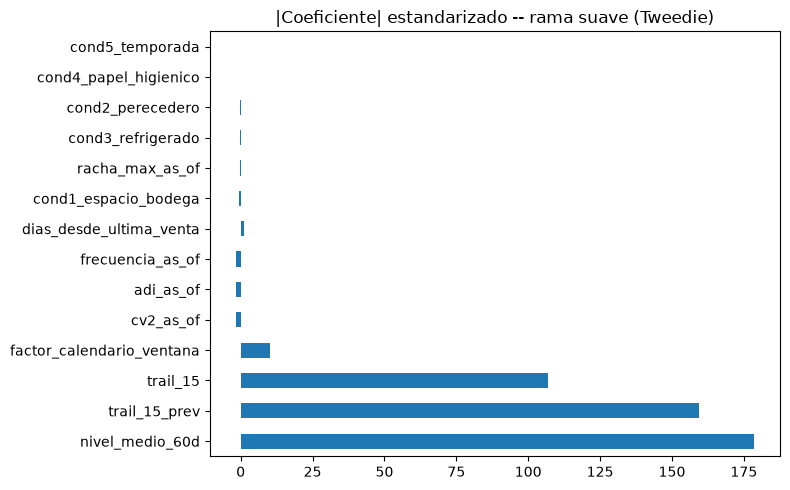


Importancia de features (rama intermitente, LightGBM, diagnóstico sobre toda la matriz):
adi_as_of                    5617
factor_calendario_ventana    5491
dias_desde_ultima_venta      5415
racha_max_as_of              5090
cv2_as_of                    4001
nivel_medio_60d              2569
frecuencia_as_of             2033
trail_15                     1192
trail_15_prev                1004
cond5_temporada               482
cond2_perecedero              396
cond3_refrigerado              87
cond1_espacio_bodega           41
cond4_papel_higienico           0
dtype: int32


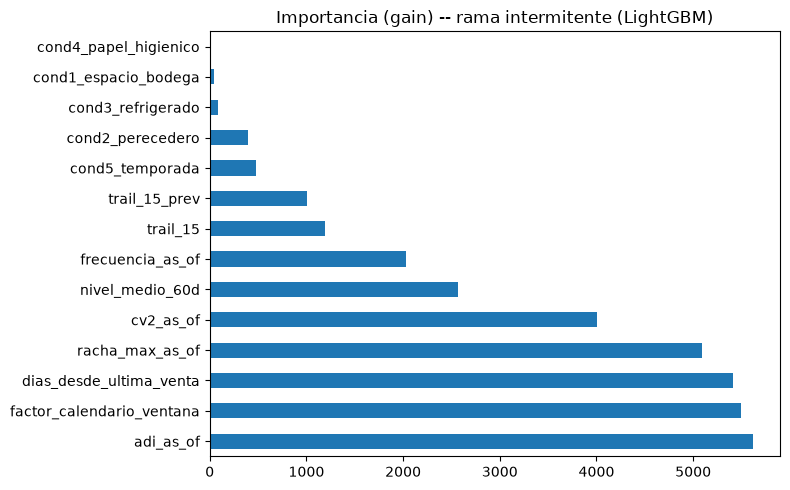


--- WAPE POR ORIGEN (los marcados son los de ORIGENES_BASELINE) ---
                                        n  wape_q50  wape_media_movil
fecha_origen es_origen_baseline                                      
2024-06-01   True               4,453.000     0.372             0.315
2024-12-01   True               5,153.000     0.338             0.346
2025-02-01   True               5,408.000     0.390             0.515

peor origen para el modelo: 2025-01-16 (WAPE 0.417)


In [8]:
# INV-62: la rama suave ahora es un GLM Tweedie (lineal), no un arbol -- no
# tiene feature_importances_. Se reporta el |coeficiente| sobre features
# ESTANDARIZADAS (solo para este diagnostico, no cambia los modelos
# entrenados en la celda anterior) para que la escala de cada feature no
# distorsione la comparacion. La rama intermitente sigue con LightGBM, ahi
# la importancia por gain sigue siendo directa.
m_suave = matriz['familia_modelo'] == 'suave'
X_suave = matriz.loc[m_suave, FEATURES]
X_suave_std = (X_suave - X_suave.mean()) / X_suave.std().replace(0, 1)
modelo_diag_suave = TweedieRegressor(**MODELOS_POR_RAMA['suave_no_perecedero']['hparams_tweedie'])
modelo_diag_suave.fit(X_suave_std, matriz.loc[m_suave, TARGET])
coef = pd.Series(modelo_diag_suave.coef_, index=FEATURES).sort_values(key=np.abs, ascending=False)
print('Coeficientes estandarizados (rama suave, SOLO el componente Tweedie del ensamble '
      '-- no incluye la mitad LightGBM, diagnóstico sobre toda la matriz):')
print(coef)
coef.plot(kind='barh', figsize=(8, 5), title='|Coeficiente| estandarizado -- rama suave (Tweedie)')
plt.tight_layout(); plt.show()

m_inter = matriz['familia_modelo'] == 'intermitente'
modelo_diag_inter = lgb.LGBMRegressor(objective='quantile', alpha=0.5, subsample_freq=1,
                                       random_state=SEMILLA, verbose=-1,
                                       **MODELOS_POR_RAMA['intermitente']['hparams'])
modelo_diag_inter.fit(matriz.loc[m_inter, FEATURES], matriz.loc[m_inter, TARGET])
imp = pd.Series(modelo_diag_inter.feature_importances_, index=FEATURES).sort_values(ascending=False)
print('\nImportancia de features (rama intermitente, LightGBM, diagnóstico sobre toda la matriz):')
print(imp)
imp.plot(kind='barh', figsize=(8, 5), title='Importancia (gain) -- rama intermitente (LightGBM)')
plt.tight_layout(); plt.show()

print('\n--- WAPE POR ORIGEN (los marcados son los de ORIGENES_BASELINE) ---')
por_origen = (evaluacion.dropna(subset=['pred_q50'])
              .groupby(['fecha_origen', 'es_origen_baseline'])
              .apply(lambda g: pd.Series({
                  'n': len(g),
                  'wape_q50': wape(g[TARGET], g['pred_q50']),
                  'wape_media_movil': wape(g[TARGET], g['pred_media_movil_15d']),
              }), include_groups=False).round(3))
print(por_origen.loc[por_origen.index.get_level_values('es_origen_baseline')])
peor = por_origen['wape_q50'].idxmax()
print(f'\npeor origen para el modelo: {peor[0].date()} (WAPE {por_origen.loc[peor, "wape_q50"]:.3f})')

## 7. Exportación y huella

Se exporta la evaluación completa y un resumen. Si el 06 habilitó el Nivel 2, este archivo es
su insumo: lleva `pred_q_negocio` como la demanda proyectada que el clasificador cruzará
contra el stock.

In [9]:
assert evaluacion['pred_q50'].notna().any(), 'ninguna rama produjo predicciones'
assert not evaluacion.loc[evaluacion['pred_q50'].notna(), 'rama'].isna().any(), 'predicción sin rama asignada'

evaluacion.to_parquet(f'{DW}/evaluacion_nivel_1.parquet', index=False)
tabla.to_csv(f'{DW}/resultados_nivel_1_por_fold.csv', index=False)
agregado.to_csv(f'{DW}/resultados_nivel_1_por_rama.csv')

resumen = {
    'notebook': '08_nivel1_demanda',
    'fecha_generacion': pd.Timestamp.now().isoformat(),
    'costos_supuestos': COSTOS_SUPUESTOS,
    'alpha_negocio': ALPHA_NEGOCIO,
    'features_usadas': FEATURES,
    'resultados_por_rama': agregado.reset_index().to_dict('records'),
    'entradas': registrar_huella(['matriz_as_of.parquet', 'piso_interno_por_patron.csv',
                                  'piso_baseline_por_patron.csv', 'panel_diario.parquet']),
    'salidas': registrar_huella(['evaluacion_nivel_1.parquet',
                                 'resultados_nivel_1_por_fold.csv',
                                 'resultados_nivel_1_por_rama.csv']),
}
with open(f'{DW}/huella_08.json', 'w') as f:
    json.dump(resumen, f, indent=2, ensure_ascii=False, default=str)
print('guardado: evaluacion_nivel_1.parquet, resultados_nivel_1_*.csv, huella_08.json')

guardado: evaluacion_nivel_1.parquet, resultados_nivel_1_*.csv, huella_08.json


## 8. Qué queda pendiente

1. **Validar los costos con el negocio.** Mientras `Cu` y `Co` sean supuestos, el cuantil de
   la rama perecedera debe reportarse como rango (ver la tabla de sensibilidad de la
   sección 1), no como 0.17.
2. **Resolver la tensión de la rama perecedera.** Si el cuantil bajo se confirma, hay que
   escribir explícitamente en la tesis que el sistema sub-pronostica perecederos por diseño
   de costos, y que la alerta de desabastecimiento para esa rama debe apoyarse en el Nivel 2
   y no en el cuantil del Nivel 1.
3. **Nivel 2**: sólo si el 06 lo habilitó. Si no, documentarlo como limitación del dato y
   plantear la alerta como regla determinística sobre `pred_q_negocio` contra el stock.
4. **Calibración -- YA SE APLICÓ recalibración conformal (split-CQR) a `suave_perecedero`**
   (`dw/probar_conformal_nivel1.py`, sección 4, ronda 4): mejoró la cobertura empírica de
   0.045 a 0.098 (objetivo 0.167 -- sigue sin llegar, pero el desvío bajó de 0.122 a 0.069,
   ~43%). NO se aplicó a las otras 2 ramas: ahí el conformal EMPEORA una calibración que ya
   estaba bien (intermitente 0.011→0.025 de desvío; suave_no_perecedero 0.007→0.046) --
   corregir donde no hay problema solo agrega ruido. `suave_perecedero` sigue sin estar
   lista para la alerta de negocio en producción.
5. **Validación de generalización -- YA SE HIZO (ronda 4,
   `dw/validar_generalizacion_nivel1.py`)**, dos hallazgos honestos que cambian cómo se
   lee la sección 5:
   - `intermitente` gana al piso en 3 de 4 folds (pierde en el fold 2) y **sigue ganando
     incluso excluyendo el fold 5** (+0.6% vs +1.7% con él) -- resultado razonablemente
     robusto.
   - `suave_no_perecedero` **gana SOLO gracias al fold 5**: excluyéndolo, el agregado se
     da vuelta y PIERDE por 1.8%. El "supera el piso por primera vez" de la sección 4 no
     debe leerse como un resultado confirmado, es frágil a qué tramo de tiempo se mida.
   - Semilla alternativa (123 vs 42, mismos folds): diferencia < 0.002 en wape_q50 en las
     3 ramas -- no es sensible a la aleatoriedad del entrenamiento, la fragilidad de
     `suave_no_perecedero` es temporal (qué folds se incluyen), no de inicialización.
   - Limitación explícita: esto NO es una validación cruzada con un corte de folds
     completamente distinto (eso requeriría reconstruir `matriz_as_of.parquet` con
     fronteras de fold nuevas en 07) -- es la aproximación más rigurosa posible sin
     rehacer 07, documentada como tal.
6. **Dos intentos que NO funcionaron para arreglar la calibración de `suave_perecedero`,
   documentados para no repetirlos**: un modelo hurdle (clasificador de cero + regresión
   sobre positivos) fue descartado porque la premisa era falsa -- esa rama no tiene NINGUNA
   fila con target exactamente 0 en entrenamiento (es una suma de 15 días). Un ajuste en
   escala `log1p`/`expm1` disparó el WAPE a 7.1 (50x peor que el piso) -- la cola pesada del
   target (skew 5.4) hace que errores chicos en escala log se vuelvan enormes al invertir
   sin corrección de smearing de Duan. Ninguno de los dos se llevó a producción.
7. **Más búsqueda, si se quiere seguir exprimiendo esto**: ya se cubrió LightGBM/HistGB/
   Tweedie con optuna y un ensamble de los dos ganadores -- lo que falta es (a) validar
   cruzado con otro corte de folds (punto 5); (b) agregar 2022 (sin noviembre-diciembre,
   decisión explícita: se deja para una fase futura) específicamente beneficiaría a las
   ramas suaves, que son las que tienen menos filas de entrenamiento por fold.